## 0. Introduction



## 1. Import Library and Setup

In [1]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, multilabel_confusion_matrix
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# setup reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 2. Load Data

In [2]:
df_train_raw = pd.read_csv('data/medical_tc_train.csv')
df_test_raw = pd.read_csv('data/medical_tc_test.csv')

## 2. Pre-processing

In [3]:
# aggregate by abstract (multi‑label per abstract)
df_train_grouped = df_train_raw.groupby('medical_abstract')['condition_label'].apply(list).reset_index()
df_test_grouped = df_test_raw.groupby('medical_abstract')['condition_label'].apply(list).reset_index()

# multi-label binarisation (classes 1..5)
mlb = MultiLabelBinarizer(classes=[1, 2, 3, 4, 5])
y_train_binary = mlb.fit_transform(df_train_grouped['condition_label'])
y_test_binary = mlb.transform(df_test_grouped['condition_label'])

## 3. Data Splitting

In [4]:
X_train_text, X_val_text, y_train, y_val = train_test_split(
    df_train_grouped['medical_abstract'].values,
    y_train_binary,
    test_size=0.15,
    random_state=SEED
)

## 4. Dataset Preparation for Training Needs

In [5]:
# initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

# define custom wrapper dataset
class MedicalCorpusDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = " ".join(str(self.texts[idx]).split())
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'targets': torch.tensor(self.labels[idx], dtype=torch.float)
        }

# create datasets
train_dataset = MedicalCorpusDataset(X_train_text, y_train, tokenizer)
val_dataset   = MedicalCorpusDataset(X_val_text,   y_val,   tokenizer)
test_dataset  = MedicalCorpusDataset(df_test_grouped['medical_abstract'].values, y_test_binary, tokenizer)

In [6]:
# initialize data loader
BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

## 5. Model Architecture

In [7]:
class BioClinicalBERT(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.bert = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
        self.drop = nn.Dropout(p=0.3)
        self.out = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.pooler_output
        return self.out(self.drop(pooled))

model = BioClinicalBERT(n_classes=5).to(device)
print(model)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BioClinicalBERT(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_a

## 6. Setup for Imbalanced Class Handling

In [8]:
# imbalanced class handling: pos_weight
positive_counts = y_train.sum(axis=0)
negative_counts = y_train.shape[0] - positive_counts
pos_weights = torch.tensor(negative_counts / positive_counts, dtype=torch.float).to(device)
print("pos weights per class:", pos_weights.cpu().numpy())

pos weights per class: [2.7531557 6.9563923 5.1849    2.8174038 1.4633323]


## 7. Model Development

### 7.1 Training Setup

In [9]:
# training setup
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
EPOCHS = 9
optimizer = AdamW(model.parameters(), lr=3e-5)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

### 7.2 Define Subprograms Needed

In [10]:
def train_epoch(model, loader, criterion, optimizer, device, scheduler):
    model.train()
    total_loss = 0
    
    pbar = tqdm(loader, desc="  Training", leave=False)
    
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        targets = batch['targets'].to(device)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, targets)

        total_loss += loss.item()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        
        # Update info loss di progress bar
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    return total_loss / len(loader)

def evaluate(model, loader, device, threshold=0.5):
    model.eval()
    preds_list, true_list = [], []
    total_loss = 0
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="  Evaluating", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            targets = batch['targets'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, targets)
            total_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = (probs > threshold).int()
            
            preds_list.extend(preds.cpu().numpy())
            true_list.extend(targets.cpu().numpy())
            
    return np.array(preds_list), np.array(true_list), total_loss / len(loader)

### 7.3 Training Loop

In [11]:
train_losses, val_losses = [], []
best_val_loss = float('inf')
best_val_f1 = -1.0

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device, scheduler)
    
    y_val_pred, y_val_true, val_loss = evaluate(model, val_loader, device)
    
    val_f1 = f1_score(y_val_true, y_val_pred, average='macro')
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Result -> Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro F1: {val_f1:.4f}")

    # checkpoints
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model_by_loss.pt')
        print(f"Best loss model saved: {best_val_loss:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_model_by_f1.pt')
        print(f"Best F1 model saved: {best_val_f1:.4f}")


Epoch 1/9


  Training:   0%|          | 0/1004 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/178 [00:00<?, ?it/s]

Result -> Train Loss: 0.5694 | Val Loss: 0.4865 | Val Macro F1: 0.7683
Best loss model saved: 0.4865
Best F1 model saved: 0.7683

Epoch 2/9


  Training:   0%|          | 0/1004 [00:00<?, ?it/s]

...

  Evaluating:   0%|          | 0/178 [00:00<?, ?it/s]

Result -> Train Loss: 0.0464 | Val Loss: 0.8904 | Val Macro F1: 0.7957

Epoch 9/9


  Training:   0%|          | 0/1004 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/178 [00:00<?, ?it/s]

Result -> Train Loss: 0.0307 | Val Loss: 0.8911 | Val Macro F1: 0.7967


## 8. Evaluation

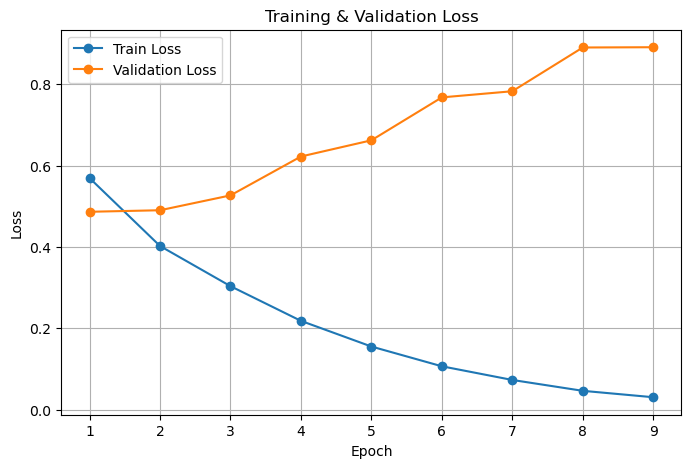

In [12]:
# visualize training history
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, EPOCHS + 1), val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('training_history.png', dpi=150)
plt.show()

In [13]:
class_names = ['Neoplasms', 'Digestive', 'Nervous', 'Cardiovascular', 'General Patho']

def evaluate_and_print(model_path, model_name, test_loader, device, class_names):
    model = BioClinicalBERT(n_classes=5).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    y_pred, y_true, test_loss = evaluate(model, test_loader, device)
    
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    
    print(f"\n{'='*60}")
    print(f"EVALUATION ON TEST SET: {model_name}")
    print(f"{'='*60}")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Macro F1-Score: {macro_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    
    # per-label confusion matrices
    conf_matrices = multilabel_confusion_matrix(y_true, y_pred)
    print("\nPer-label Confusion Matrices (TN, FP, FN, TP):")
    for i, name in enumerate(class_names):
        tn, fp, fn, tp = conf_matrices[i].ravel()
        print(f"{name:15} | TN: {tn:4} | FP: {fp:4} | FN: {fn:4} | TP: {tp:4}")
    
    return macro_f1, test_loss

# evaluation: best loss expected
f1_loss_model, loss_loss_model = evaluate_and_print('best_model_by_loss.pt', 'Best Model by Validation Loss', test_loader, device, class_names)

# evaluation: best F1-macro expected
f1_f1_model, loss_f1_model = evaluate_and_print('best_model_by_f1.pt', 'Best Model by Macro F1', test_loader, device, class_names)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Evaluating:   0%|          | 0/347 [00:00<?, ?it/s]


EVALUATION ON TEST SET: Best Model by Validation Loss
Test Loss: 0.5312
Macro F1-Score: 0.6858

Classification Report:
                precision    recall  f1-score   support

     Neoplasms       0.71      0.88      0.78       633
     Digestive       0.49      0.93      0.64       299
       Nervous       0.56      0.85      0.67       385
Cardiovascular       0.64      0.92      0.75       610
 General Patho       0.49      0.70      0.58       961

     micro avg       0.57      0.83      0.68      2888
     macro avg       0.58      0.86      0.69      2888
  weighted avg       0.58      0.83      0.68      2888
   samples avg       0.63      0.84      0.69      2888


Per-label Confusion Matrices (TN, FP, FN, TP):
Neoplasms       | TN: 1905 | FP:  232 | FN:   77 | TP:  556
Digestive       | TN: 2184 | FP:  287 | FN:   21 | TP:  278
Nervous         | TN: 2123 | FP:  262 | FN:   58 | TP:  327
Cardiovascular  | TN: 1837 | FP:  323 | FN:   47 | TP:  563
General Patho   | TN: 1118 | 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Evaluating:   0%|          | 0/347 [00:00<?, ?it/s]


EVALUATION ON TEST SET: Best Model by Macro F1
Test Loss: 1.2301
Macro F1-Score: 0.6074

Classification Report:
                precision    recall  f1-score   support

     Neoplasms       0.67      0.80      0.73       633
     Digestive       0.49      0.57      0.52       299
       Nervous       0.50      0.69      0.58       385
Cardiovascular       0.62      0.78      0.69       610
 General Patho       0.46      0.57      0.51       961

     micro avg       0.55      0.68      0.61      2888
     macro avg       0.55      0.68      0.61      2888
  weighted avg       0.55      0.68      0.61      2888
   samples avg       0.57      0.69      0.61      2888


Per-label Confusion Matrices (TN, FP, FN, TP):
Neoplasms       | TN: 1889 | FP:  248 | FN:  128 | TP:  505
Digestive       | TN: 2292 | FP:  179 | FN:  129 | TP:  170
Nervous         | TN: 2123 | FP:  262 | FN:  119 | TP:  266
Cardiovascular  | TN: 1870 | FP:  290 | FN:  133 | TP:  477
General Patho   | TN: 1149 | FP:  66